In [1]:
# =========================================================
# Import Required Libraries
# ---------------------------------------------------------
# numpy & pandas → numerical operations and data handling
# matplotlib → visualization
# sklearn → dataset loading, preprocessing, evaluation
# tensorflow.keras → building and training neural networks
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

print("All imports completed!")

All imports completed!


In [2]:
# =========================================================
# Load Iris Dataset
# ---------------------------------------------------------
# The Iris dataset contains 150 samples of iris flowers
# with 4 numerical features:
#   1. Sepal length
#   2. Sepal width
#   3. Petal length
#   4. Petal width
#
# The goal is to classify the flower into one of three
# species:
#   - Setosa
#   - Versicolor
#   - Virginica
# =========================================================

iris = load_iris()

# Convert dataset into pandas DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add target column (flower species)
df["species"] = iris.target

print("Dataset Loaded. Shape:", df.shape)

df.head()

Dataset Loaded. Shape: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
# =========================================================
# Data Preprocessing
# ---------------------------------------------------------
# Separate input features (X) and target labels (y)
# Then encode labels and convert them into categorical
# format required by neural networks.
# =========================================================

# Features
X = df.drop("species", axis=1)

# Target
y = df["species"]

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Convert labels into categorical format
y_categorical = to_categorical(y_encoded)

print("Classes:", iris.target_names)

Classes: ['setosa' 'versicolor' 'virginica']


In [4]:
# =========================================================
# Feature Scaling and Train-Test Split
# ---------------------------------------------------------
# StandardScaler normalizes the feature values so that
# each feature has mean = 0 and standard deviation = 1.
#
# This improves neural network training performance.
#
# Dataset is split into:
#   80% Training Data
#   20% Testing Data
# =========================================================

scaler = StandardScaler()

# Normalize features
X_scaled = scaler.fit_transform(X)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_categorical,
    test_size=0.2,
    random_state=42
)

print("Train/Test split done:")
print("X_train:", X_train.shape, "X_test:", X_test.shape)

Train/Test split done:
X_train: (120, 4) X_test: (30, 4)


In [5]:
# =========================================================
# Neural Network Model Builder
# ---------------------------------------------------------
# This function creates a neural network model with
# a specified activation function.
#
# Architecture:
# Input Layer → 4 features
# Hidden Layer 1 → 16 neurons
# Hidden Layer 2 → 8 neurons
# Output Layer → 3 neurons (softmax for classification)
# =========================================================

def build_model(activation_function):

    model = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(16, activation=activation_function),
        Dense(8, activation=activation_function),
        Dense(3, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

print("Model builder ready!")

Model builder ready!


In [6]:
# =========================================================
# Train Model Using Different Activation Functions
# ---------------------------------------------------------
# We test three activation functions:
#   1. ReLU
#   2. Tanh
#   3. Sigmoid
#
# Each model is trained and evaluated.
# The best activation function is selected based on
# validation accuracy.
# =========================================================

activations = ["relu", "tanh", "sigmoid"]

histories = {}
final_accuracies = {}

best_model = None
best_accuracy = 0
best_activation = None

for act in activations:

    print(f"\nTraining with {act} activation...")

    model = build_model(act)

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_test, y_test),
        epochs=100,
        batch_size=8,
        callbacks=[early_stop],
        verbose=1
    )

    val_acc = max(history.history["val_accuracy"])

    histories[act] = history
    final_accuracies[act] = val_acc

    if val_acc > best_accuracy:
        best_accuracy = val_acc
        best_model = model
        best_activation = act

print(f"\nBest Activation: {best_activation} with Val Accuracy: {best_accuracy:.4f}")


Training with relu activation...
Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.4017 - loss: 1.0301 - val_accuracy: 0.3667 - val_loss: 0.9816
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3487 - loss: 1.0154 - val_accuracy: 0.5333 - val_loss: 0.9375
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5266 - loss: 0.9281 - val_accuracy: 0.6333 - val_loss: 0.8990
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5638 - loss: 0.9289 - val_accuracy: 0.6333 - val_loss: 0.8636
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5446 - loss: 0.8596 - val_accuracy: 0.6667 - val_loss: 0.8276
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6654 - loss: 0.7893 - val_accuracy: 0.7333 - val_loss: 0.7940
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6353 - loss: 0.7754 - val_accuracy: 0.8000 - val_loss: 0.7639
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7360 - 

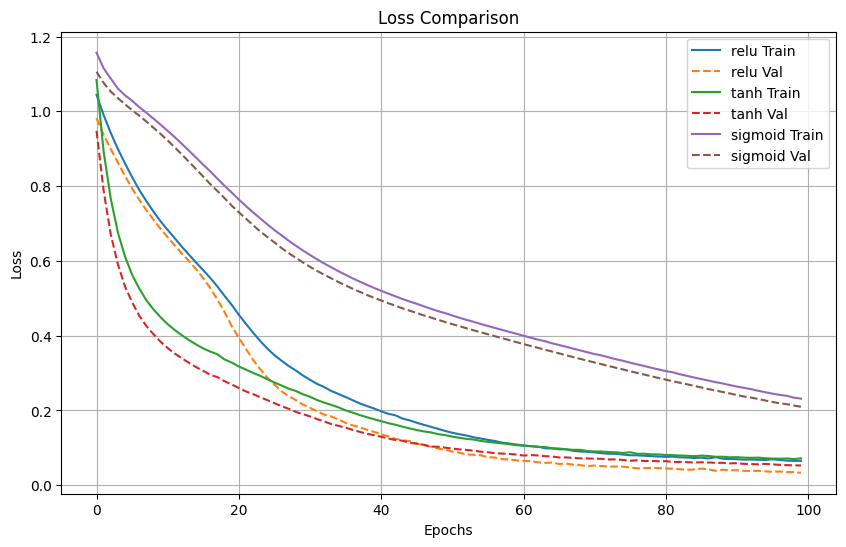

In [7]:
# =========================================================
# Plot Loss Comparison
# ---------------------------------------------------------
# This graph compares training and validation loss
# for each activation function during training.
# Lower loss indicates better model performance.
# =========================================================

plt.figure(figsize=(10,6))

for act in activations:
    plt.plot(histories[act].history["loss"], label=f"{act} Train")
    plt.plot(histories[act].history["val_loss"], linestyle="--", label=f"{act} Val")

plt.title("Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

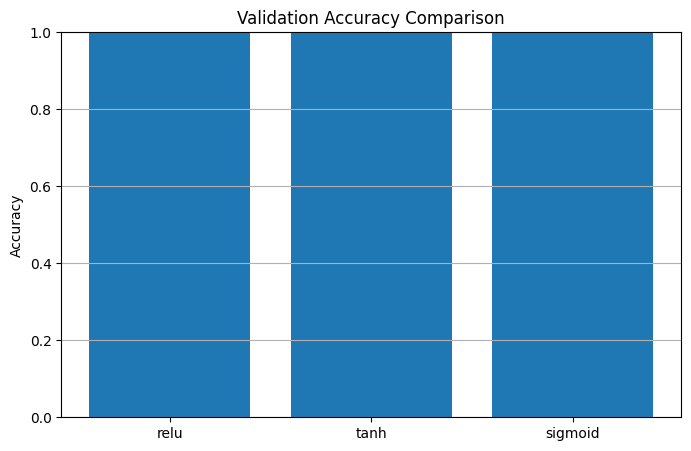

relu: 1.0000
tanh: 1.0000
sigmoid: 1.0000


In [8]:
# =========================================================
# Compare Validation Accuracy
# ---------------------------------------------------------
# A bar chart is used to visualize which activation
# function provides the best accuracy.
# =========================================================

plt.figure(figsize=(8,5))

plt.bar(final_accuracies.keys(), final_accuracies.values())

plt.title("Validation Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)

plt.grid(axis="y")

plt.show()

for act, acc in final_accuracies.items():
    print(f"{act}: {acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step


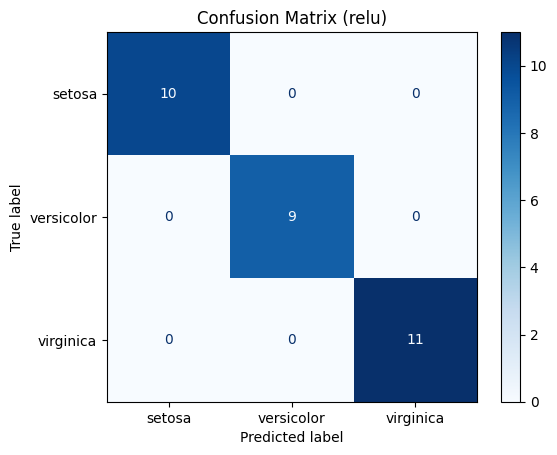

In [9]:
# =========================================================
# Confusion Matrix
# ---------------------------------------------------------
# Shows how well the model classifies each flower species.
# Rows represent actual labels and columns represent
# predicted labels.
# =========================================================

y_pred_probs = best_model.predict(X_test)

y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp.plot(cmap="Blues")

plt.title(f"Confusion Matrix ({best_activation})")
plt.grid(False)

plt.show()

In [10]:
# =========================================================
# Classification Report
# ---------------------------------------------------------
# Provides important evaluation metrics including:
#   Precision
#   Recall
#   F1-score
#   Accuracy
# =========================================================

print("Classification Report:")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=iris.target_names
    )
)

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [11]:
# =========================================================
# Manual Hard-coded Prediction
# ---------------------------------------------------------
# Provide a custom flower measurement and let the model
# predict which Iris species it belongs to.
# =========================================================

custom_values = [5.1, 3.5, 1.4, 0.2]

custom_input = np.array(custom_values).reshape(1, -1)

# Apply same scaling used during training
custom_input_scaled = scaler.transform(custom_input)

prediction = best_model.predict(custom_input_scaled)

predicted_index = np.argmax(prediction)

predicted_label = iris.target_names[predicted_index]

print("\n==============================")
print(" Iris Flower Prediction ")
print("==============================")

print("\nGiven Input:")

for name, val in zip(X.columns, custom_values):
    print(f"{name}: {val}")

print("\nPredicted Flower:", predicted_label)

print("\nPrediction Probabilities:")

for cls, prob in zip(iris.target_names, prediction[0]):
    print(f"{cls}: {prob:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step

 Iris Flower Prediction 

Given Input:
sepal length (cm): 5.1
sepal width (cm): 3.5
petal length (cm): 1.4
petal width (cm): 0.2

Predicted Flower: setosa

Prediction Probabilities:
setosa: 0.9996
versicolor: 0.0004
virginica: 0.0000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


3759/3759 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step


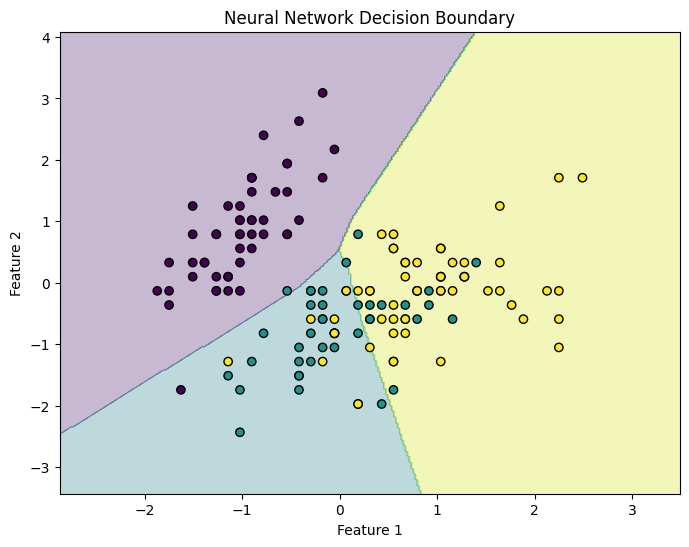

In [12]:
# =========================================================
# Decision Boundary Visualization
# ---------------------------------------------------------
# Since Iris has 4 features, we use only the first two
# features to visualize how the neural network separates
# different classes.
# =========================================================

X_vis = X_scaled[:, :2]

X_train_vis, X_test_vis, y_train_vis, y_test_vis = train_test_split(
    X_vis,
    y_categorical,
    test_size=0.2,
    random_state=42
)

model_vis = Sequential([
    Input(shape=(2,)),
    Dense(16, activation=best_activation),
    Dense(8, activation=best_activation),
    Dense(3, activation="softmax")
])

model_vis.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_vis.fit(X_train_vis, y_train_vis, epochs=100, verbose=0)

x_min, x_max = X_vis[:,0].min()-1, X_vis[:,0].max()+1
y_min, y_max = X_vis[:,1].min()-1, X_vis[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

grid = np.c_[xx.ravel(), yy.ravel()]

pred = model_vis.predict(grid)

pred = np.argmax(pred, axis=1)
pred = pred.reshape(xx.shape)

plt.figure(figsize=(8,6))

plt.contourf(xx, yy, pred, alpha=0.3)

plt.scatter(
    X_vis[:,0],
    X_vis[:,1],
    c=np.argmax(y_categorical, axis=1),
    edgecolor="k"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Neural Network Decision Boundary")

plt.show()